# 딥러닝 입문: 신경망 기초

이번 차시에서는 딥러닝의 핵심 구성요소인 **인공 신경망(Artificial Neural Network)** 의 기초 원리를 학습함. 생물학적 뉴런에서 영감을 받은 인공 뉴런의 수학적 모델링부터 시작하여, 순전파(Forward Propagation)와 역전파(Backpropagation) 알고리즘의 원리를 단계별로 이해함. 이론적 학습과 함께 실제 산업 데이터를 활용한 신경망 구현 실습을 통해 딥러닝의 핵심 개념을 체득함.

### 학습 목표

1. 인공 뉴런의 수학적 원리를 이해하고 직접 계산할 수 있음
2. 활성화 함수의 종류, 수학적 정의, 역할을 파악함
3. 신경망 구조 설계와 파라미터 수 계산을 수행함
4. 순전파와 역전파의 수학적 원리를 연쇄 법칙을 통해 이해함
5. XOR 문제와 실제 제조 데이터를 통해 신경망의 비선형 학습 능력을 확인함

---

## 실습 데이터셋 소개

### UCI Hydraulic System Condition Monitoring Dataset

본 실습에서는 UCI Machine Learning Repository에서 제공하는 **유압 시스템 상태 모니터링 데이터셋**을 활용함. 이 데이터셋은 실제 유압 테스트 리그에서 수집된 센서 데이터로, 제조 현장에서의 예측 유지보수(Predictive Maintenance) 시나리오를 대표함.

#### 데이터셋 개요

| 항목 | 내용 |
|------|------|
| **출처** | UCI Machine Learning Repository |
| **샘플 수** | 2,205개 |
| **센서 종류** | 17개 (압력, 온도, 유량, 진동, 효율, 전력 등) |
| **추출 특징 수** | 85개 (센서당 평균, 표준편차, 최소, 최대, 범위) |
| **분류 대상** | 밸브 상태 (4개 클래스: 100%, 90%, 80%, 73%) |

#### 센서 구성

```
압력 센서 (PS1-PS6): 6개 x 6,000 측정점/사이클
온도 센서 (TS1-TS4): 4개 x 60 측정점/사이클
유량 센서 (FS1, FS2): 2개 x 600 측정점/사이클
진동 센서 (VS1): 1개 x 60 측정점/사이클
효율 센서 (SE): 1개 x 60 측정점/사이클
냉각 효율 (CE): 1개 x 60 측정점/사이클
냉각 전력 (CP): 1개 x 60 측정점/사이클
전력 소비 (EPS1): 1개 x 6,000 측정점/사이클
```

#### 분류 레이블: 밸브 상태 (Valve Condition)

| 레이블 값 | 의미 | 샘플 수 |
|----------|------|--------|
| 100 | 최적 상태 (100% 효율) | 1,125개 |
| 90 | 경미한 성능 저하 (90% 효율) | 360개 |
| 80 | 중간 성능 저하 (80% 효율) | 360개 |
| 73 | 심각한 성능 저하 (73% 효율) | 360개 |

이 데이터셋은 클래스 불균형이 존재하며, 실제 제조 현장의 특성을 반영함 (정상 상태가 다수, 고장 상태가 소수).

---

## 환경 설정 및 라이브러리 로드

In [2]:
# 필수 라이브러리 임포트
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정
plt.rcParams['font.family'] = ['DejaVu Sans', 'NanumGothic', 'Malgun Gothic', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False

# 시각화 스타일 설정
plt.style.use('seaborn-v0_8-whitegrid')

# 재현성을 위한 시드 설정
np.random.seed(114)

# 1. 인공 뉴런의 수학적 기초

## 1.1 머신러닝에서 딥러닝으로의 발전

전통적인 머신러닝과 딥러닝의 근본적인 차이점은 **특성 추출(Feature Extraction)** 방식에 있음.

### 머신러닝 vs 딥러닝 비교

```mermaid
flowchart LR
    subgraph ML["전통적 머신러닝"]
        direction LR
        A1["원시 데이터"] --> B1["수동 특성 추출"]
        B1 --> C1["ML 모델"]
        C1 --> D1["예측"]
    end
    
    subgraph DL["딥러닝"]
        direction LR
        A2["원시 데이터"] --> B2["신경망"]
        B2 --> C2["자동 특성 학습"]
        C2 --> D2["예측"]
    end
```

| 구분 | 전통적 머신러닝 | 딥러닝 |
|------|----------------|--------|
| **대표 모델** | 랜덤 포레스트, SVM, 로지스틱 회귀 | 다층 퍼셉트론, CNN, RNN, Transformer |
| **특성 추출** | 도메인 전문가가 수동으로 설계 | 신경망이 자동으로 학습 |
| **데이터 양** | 상대적으로 적은 데이터로도 가능 | 대규모 데이터에서 효과적 |
| **계산 자원** | CPU로 충분 | GPU/TPU 권장 |
| **해석 가능성** | 상대적으로 높음 | 상대적으로 낮음 (블랙박스) |
| **적합한 문제** | 정형 데이터, 도메인 지식 활용 가능 | 이미지, 음성, 자연어 등 비정형 데이터 |

## 1.2 생물학적 뉴런과 인공 뉴런

인공 신경망은 인간 뇌의 신경세포(뉴런) 작동 원리에서 영감을 받아 설계됨.

### 생물학적 뉴런의 구조

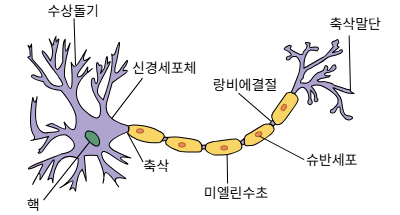


- **수상돌기(Dendrites)**: 다른 뉴런으로부터 신호를 수신
- **세포체(Soma)**: 수신된 신호를 통합하고, 역치(threshold)를 초과하면 발화(fire)
- **축삭(Axon)**: 발화된 신호를 다음 뉴런으로 전달

### 인공 뉴런(Perceptron)의 구조

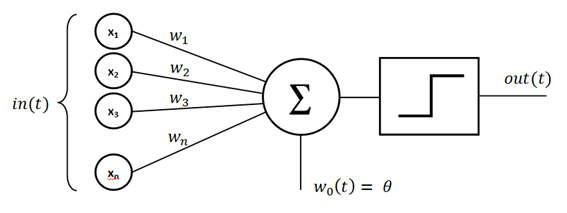

## 1.3 인공 뉴런의 수학적 정의

### 뉴런 출력의 수학적 표현

인공 뉴런의 출력은 다음 두 단계로 계산됨:

**Step 1: 가중합(Weighted Sum) 계산**

$$z = \sum_{i=1}^{n} w_i x_i + b = w_1 x_1 + w_2 x_2 + \cdots + w_n x_n + b$$

벡터 표기법으로는:

$$z = \mathbf{w}^T \mathbf{x} + b$$

여기서:
- $\mathbf{x} = [x_1, x_2, \ldots, x_n]^T$: 입력 벡터
- $\mathbf{w} = [w_1, w_2, \ldots, w_n]^T$: 가중치 벡터
- $b$: 편향(bias)

**Step 2: 활성화 함수(Activation Function) 적용**

$$a = f(z)$$

**최종 출력 공식:**

$$\boxed{a = f\left(\sum_{i=1}^{n} w_i x_i + b\right) = f(z)}$$

### 각 요소의 의미

| 요소 | 기호 | 의미 | 역할 |
|------|------|------|------|
| 입력 | $x_i$ | i번째 입력 특성값 | 데이터의 특성 |
| 가중치 | $w_i$ | i번째 입력의 중요도 | 학습을 통해 조정 |
| 편향 | $b$ | 기준점(threshold) 조정 | 결정 경계 이동 |
| 가중합 | $z$ | 선형 결합 결과 | 중간 계산값 |
| 활성화 함수 | $f$ | 비선형 변환 | 비선형성 부여 |
| 출력 | $a$ | 뉴런의 최종 출력 | 다음 층으로 전달 |

## 1.4 뉴런 계산 예시: 단계별 수치 계산

### 예제: 2개의 입력을 가진 뉴런

주어진 값:
- 입력: $x_1 = 0.5$, $x_2 = 0.3$
- 가중치: $w_1 = 0.8$, $w_2 = -0.2$
- 편향: $b = 0.1$
- 활성화 함수: Sigmoid

**Step 1: 가중합 계산**

$$z = w_1 \cdot x_1 + w_2 \cdot x_2 + b$$
$$z = (0.8 \times 0.5) + (-0.2 \times 0.3) + 0.1$$
$$z = 0.4 + (-0.06) + 0.1$$
$$z = 0.44$$

**Step 2: Sigmoid 활성화 함수 적용**

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$
$$a = \sigma(0.44) = \frac{1}{1 + e^{-0.44}} = \frac{1}{1 + 0.644} = \frac{1}{1.644} \approx 0.608$$

**결과**: 입력 $(0.5, 0.3)$에 대해 뉴런은 $0.608$을 출력함

In [3]:
# 뉴런 계산 예시 코드 구현
def single_neuron_forward(x, w, b, activation='sigmoid'):
    """
    단일 뉴런의 순전파 계산
    
    Parameters:
    -----------
    x : array-like, 입력 벡터
    w : array-like, 가중치 벡터
    b : float, 편향
    activation : str, 활성화 함수 종류
    
    Returns:
    --------
    z : float, 가중합
    a : float, 활성화 함수 출력
    """
    # Step 1: 가중합 계산
    z = np.dot(w, x) + b
    
    # Step 2: 활성화 함수 적용
    if activation == 'sigmoid':
        a = 1 / (1 + np.exp(-z))
    elif activation == 'relu':
        a = np.maximum(0, z)
    elif activation == 'tanh':
        a = np.tanh(z)
    else:
        a = z  # linear
    
    return z, a

# 예시 계산
x = np.array([0.5, 0.3])
w = np.array([0.8, -0.2])
b = 0.1

z, a = single_neuron_forward(x, w, b, activation='sigmoid')

print("=" * 60)
print("단일 뉴런 순전파 계산 예시")
print("=" * 60)
print(f"\n입력값 (x):     x1 = {x[0]}, x2 = {x[1]}")
print(f"가중치 (w):     w1 = {w[0]}, w2 = {w[1]}")
print(f"편향 (b):       b = {b}")
print(f"\n[Step 1] 가중합 계산:")
print(f"  z = w1*x1 + w2*x2 + b")
print(f"  z = ({w[0]} x {x[0]}) + ({w[1]} x {x[1]}) + {b}")
print(f"  z = {w[0]*x[0]:.2f} + {w[1]*x[1]:.2f} + {b}")
print(f"  z = {z:.4f}")
print(f"\n[Step 2] Sigmoid 활성화 함수 적용:")
print(f"  a = sigmoid(z) = 1 / (1 + exp(-z))")
print(f"  a = 1 / (1 + exp(-{z:.4f}))")
print(f"  a = 1 / (1 + {np.exp(-z):.4f})")
print(f"  a = 1 / {1 + np.exp(-z):.4f}")
print(f"  a = {a:.4f}")
print(f"\n최종 출력: {a:.4f}")

단일 뉴런 순전파 계산 예시

입력값 (x):     x1 = 0.5, x2 = 0.3
가중치 (w):     w1 = 0.8, w2 = -0.2
편향 (b):       b = 0.1

[Step 1] 가중합 계산:
  z = w1*x1 + w2*x2 + b
  z = (0.8 x 0.5) + (-0.2 x 0.3) + 0.1
  z = 0.40 + -0.06 + 0.1
  z = 0.4400

[Step 2] Sigmoid 활성화 함수 적용:
  a = sigmoid(z) = 1 / (1 + exp(-z))
  a = 1 / (1 + exp(-0.4400))
  a = 1 / (1 + 0.6440)
  a = 1 / 1.6440
  a = 0.6083

최종 출력: 0.6083


### 가중치와 편향의 역할 시각화

가중치와 편향이 뉴런의 출력에 어떤 영향을 미치는지 시각적으로 확인해보겠음.

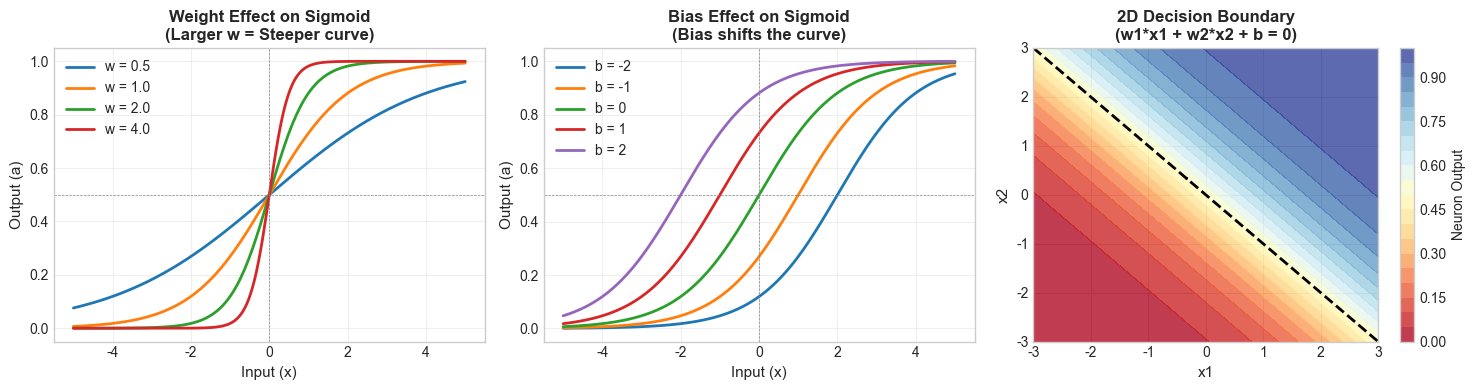


[해석]
- 가중치(w)가 클수록: Sigmoid 곡선이 더 가파르게 변화 (결정 경계가 더 명확)
- 편향(b)이 양수: 곡선이 왼쪽으로 이동 (더 쉽게 활성화)
- 편향(b)이 음수: 곡선이 오른쪽으로 이동 (더 어렵게 활성화)
- 2D에서: w1*x1 + w2*x2 + b = 0 직선이 결정 경계가 됨


In [4]:
# 가중치와 편향의 영향 시각화
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

x_range = np.linspace(-5, 5, 200)

# 1. 가중치 변화에 따른 영향 (단일 입력)
ax1 = axes[0]
for w in [0.5, 1.0, 2.0, 4.0]:
    z = w * x_range
    a = 1 / (1 + np.exp(-z))
    ax1.plot(x_range, a, linewidth=2, label=f'w = {w}')
ax1.axvline(x=0, color='gray', linestyle='--', linewidth=0.5)
ax1.axhline(y=0.5, color='gray', linestyle='--', linewidth=0.5)
ax1.set_xlabel('Input (x)', fontsize=11)
ax1.set_ylabel('Output (a)', fontsize=11)
ax1.set_title('Weight Effect on Sigmoid\n(Larger w = Steeper curve)', fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. 편향 변화에 따른 영향
ax2 = axes[1]
w = 1.0
for b in [-2, -1, 0, 1, 2]:
    z = w * x_range + b
    a = 1 / (1 + np.exp(-z))
    ax2.plot(x_range, a, linewidth=2, label=f'b = {b}')
ax2.axvline(x=0, color='gray', linestyle='--', linewidth=0.5)
ax2.axhline(y=0.5, color='gray', linestyle='--', linewidth=0.5)
ax2.set_xlabel('Input (x)', fontsize=11)
ax2.set_ylabel('Output (a)', fontsize=11)
ax2.set_title('Bias Effect on Sigmoid\n(Bias shifts the curve)', fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. 2D 결정 경계 예시
ax3 = axes[2]
xx, yy = np.meshgrid(np.linspace(-3, 3, 100), np.linspace(-3, 3, 100))
w1, w2, b = 1.0, 1.0, 0.0
z = w1 * xx + w2 * yy + b
a = 1 / (1 + np.exp(-z))
contour = ax3.contourf(xx, yy, a, levels=20, cmap='RdYlBu', alpha=0.8)
plt.colorbar(contour, ax=ax3, label='Neuron Output')
ax3.contour(xx, yy, a, levels=[0.5], colors='black', linewidths=2, linestyles='--')
ax3.set_xlabel('x1', fontsize=11)
ax3.set_ylabel('x2', fontsize=11)
ax3.set_title('2D Decision Boundary\n(w1*x1 + w2*x2 + b = 0)', fontweight='bold')

plt.tight_layout()
plt.savefig('neuron_weight_bias_effect.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n[해석]")
print("- 가중치(w)가 클수록: Sigmoid 곡선이 더 가파르게 변화 (결정 경계가 더 명확)")
print("- 편향(b)이 양수: 곡선이 왼쪽으로 이동 (더 쉽게 활성화)")
print("- 편향(b)이 음수: 곡선이 오른쪽으로 이동 (더 어렵게 활성화)")
print("- 2D에서: w1*x1 + w2*x2 + b = 0 직선이 결정 경계가 됨")

# 2 활성화 함수의 종류와 역할

## 2.1 활성화 함수의 필요성

### 활성화 함수가 없다면?

활성화 함수가 없으면 신경망은 아무리 층을 깊게 쌓아도 **선형 변환의 합성**일 뿐임.

> *이게 무슨 소리인가?*

2층 신경망에서 활성화 함수 없이:
$$h = W_1 x + b_1 \quad \text{(1층 출력)}$$
$$y = W_2 h + b_2 \quad \text{(2층 출력)}$$

대입하면:
$$y = W_2 (W_1 x + b_1) + b_2 = W_2 W_1 x + W_2 b_1 + b_2$$

$W' = W_2 W_1$, $b' = W_2 b_1 + b_2$로 놓으면:
$$\boxed{y = W' x + b'}$$

이는 단순한 **선형 변환**임. 층을 아무리 쌓아도 결국 하나의 선형 변환과 동일함.

### 비선형 활성화 함수의 역할

비선형 활성화 함수가 있으면 신경망은 **복잡한 비선형 함수**를 근사할 수 있음.

**Universal Approximation Theorem (보편 근사 정리):**
> 충분히 많은 뉴런을 가진 단일 은닉층 신경망은 어떤 연속 함수든 임의의 정밀도로 근사할 수 있다.

이것이 가능한 이유는 **비선형 활성화 함수** 덕분임.

## 2.2 주요 활성화 함수

### 1. Sigmoid 함수

**수학적 정의:**
$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

**미분:**
$$\sigma'(z) = \sigma(z) \cdot (1 - \sigma(z))$$

| 특성 | 값 |
|------|----|
| 출력 범위 | $(0, 1)$ |
| 중심값 | $\sigma(0) = 0.5$ |
| 최대 미분값 | $\sigma'(0) = 0.25$ |
| 장점 | 확률 해석 가능, 부드러운 곡선 |
| 단점 | 기울기 소실, 출력이 0 중심 아님 |
| 주요 용도 | 이진 분류의 출력층 |

**수치 계산 예시:**

| $z$ | $e^{-z}$ | $1 + e^{-z}$ | $\sigma(z)$ |
|-----|----------|--------------|-------------|
| -3 | 20.086 | 21.086 | 0.047 |
| -1 | 2.718 | 3.718 | 0.269 |
| 0 | 1.000 | 2.000 | 0.500 |
| 1 | 0.368 | 1.368 | 0.731 |
| 3 | 0.050 | 1.050 | 0.953 |

### 2. ReLU (Rectified Linear Unit)

**수학적 정의:**
$$\text{ReLU}(z) = \max(0, z) = \begin{cases} 0 & \text{if } z < 0 \\ z & \text{if } z \geq 0 \end{cases}$$

**미분:**
$$\text{ReLU}'(z) = \begin{cases} 0 & \text{if } z < 0 \\ 1 & \text{if } z > 0 \end{cases}$$

| 특성 | 값 |
|------|----|
| 출력 범위 | $[0, \infty)$ |
| 계산 비용 | 매우 낮음 |
| 장점 | 빠른 계산, **기울기 소실 완화** |
| 단점 | Dying ReLU 문제 (음수 영역에서 학습 정지) |
| 주요 용도 | 은닉층의 표준 활성화 함수 |

### 3. Tanh (Hyperbolic Tangent)

**수학적 정의:**
$$\tanh(z) = \frac{e^z - e^{-z}}{e^z + e^{-z}} = \frac{e^{2z} - 1}{e^{2z} + 1}$$

**Sigmoid와의 관계:**
$$\tanh(z) = 2\sigma(2z) - 1$$

**미분:**
$$\tanh'(z) = 1 - \tanh^2(z)$$

| 특성 | 값 |
|------|----|
| 출력 범위 | $(-1, 1)$ |
| 중심값 | $\tanh(0) = 0$ |
| 최대 미분값 | $\tanh'(0) = 1$ |
| 장점 | 출력이 0 중심 (zero-centered) |
| 단점 | 여전히 기울기 소실 존재 |

**수치 계산 예시:**

$z = 1$일 때:
$$\tanh(1) = \frac{e^1 - e^{-1}}{e^1 + e^{-1}} = \frac{2.718 - 0.368}{2.718 + 0.368} = \frac{2.350}{3.086} \approx 0.762$$

### 4. Softmax 함수

**수학적 정의:**

K개 클래스에 대한 출력 벡터 $\mathbf{z} = [z_1, z_2, \ldots, z_K]$가 주어졌을 때:

$$\text{softmax}(\mathbf{z})_i = \frac{e^{z_i}}{\sum_{j=1}^{K} e^{z_j}}$$

**특성:**
- 모든 출력값이 $(0, 1)$ 범위
- 모든 출력의 합이 정확히 1: $\sum_{i=1}^{K} \text{softmax}(\mathbf{z})_i = 1$
- 확률 분포로 해석 가능

**수치 계산 예시:**

3개 클래스의 로짓(logit): $\mathbf{z} = [2.0, 1.0, 0.5]$

| 클래스 | $z_i$ | $e^{z_i}$ | $\text{softmax}(z)_i$ |
|--------|-------|-----------|----------------------|
| 1 | 2.0 | 7.389 | $7.389 / 11.756 = 0.628$ |
| 2 | 1.0 | 2.718 | $2.718 / 11.756 = 0.231$ |
| 3 | 0.5 | 1.649 | $1.649 / 11.756 = 0.140$ |
| **합계** | - | **11.756** | **1.000** |

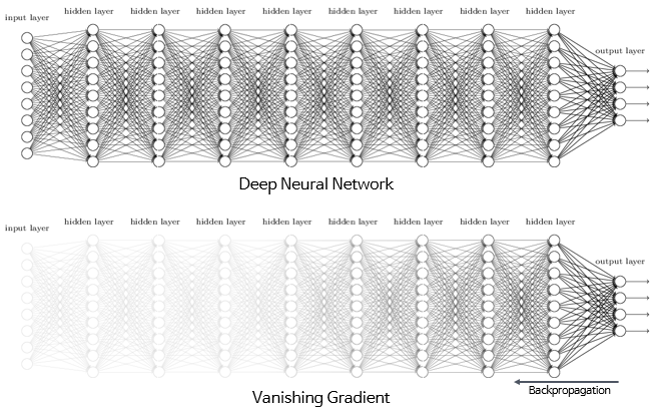


In [5]:
# 활성화 함수 구현
def sigmoid(z):
    """Sigmoid 함수: 출력 범위 (0, 1)"""
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

def sigmoid_derivative(z):
    """Sigmoid 미분: sigma(z) * (1 - sigma(z))"""
    s = sigmoid(z)
    return s * (1 - s)

def relu(z):
    """ReLU 함수: max(0, z)"""
    return np.maximum(0, z)

def relu_derivative(z):
    """ReLU 미분: z > 0 이면 1, 아니면 0"""
    return (z > 0).astype(float)

def tanh_func(z):
    """Tanh 함수: 출력 범위 (-1, 1)"""
    return np.tanh(z)

def tanh_derivative(z):
    """Tanh 미분: 1 - tanh(z)^2"""
    return 1 - np.tanh(z)**2

def softmax(z):
    """Softmax 함수: 다중 클래스 분류용"""
    # 수치 안정성을 위해 최대값을 빼줌
    if z.ndim == 1:
        exp_z = np.exp(z - np.max(z))
        return exp_z / np.sum(exp_z)
    else:
        exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)

# Softmax 계산 예시
z_example = np.array([2.0, 1.0, 0.5])
softmax_output = softmax(z_example)

print("=" * 60)
print("Softmax 계산 예시")
print("=" * 60)
print(f"\n입력 로짓 z = {z_example}")
print(f"\n계산 과정:")
print(f"  exp(z) = [{np.exp(z_example[0]):.3f}, {np.exp(z_example[1]):.3f}, {np.exp(z_example[2]):.3f}]")
print(f"  sum(exp(z)) = {np.sum(np.exp(z_example)):.3f}")
print(f"\nSoftmax 출력:")
for i, (z_i, s_i) in enumerate(zip(z_example, softmax_output)):
    print(f"  Class {i+1}: z={z_i:.1f} -> P={s_i:.3f} ({s_i*100:.1f}%)")
print(f"\n확률 합계: {np.sum(softmax_output):.6f}")

Softmax 계산 예시

입력 로짓 z = [2.  1.  0.5]

계산 과정:
  exp(z) = [7.389, 2.718, 1.649]
  sum(exp(z)) = 11.756

Softmax 출력:
  Class 1: z=2.0 -> P=0.629 (62.9%)
  Class 2: z=1.0 -> P=0.231 (23.1%)
  Class 3: z=0.5 -> P=0.140 (14.0%)

확률 합계: 1.000000


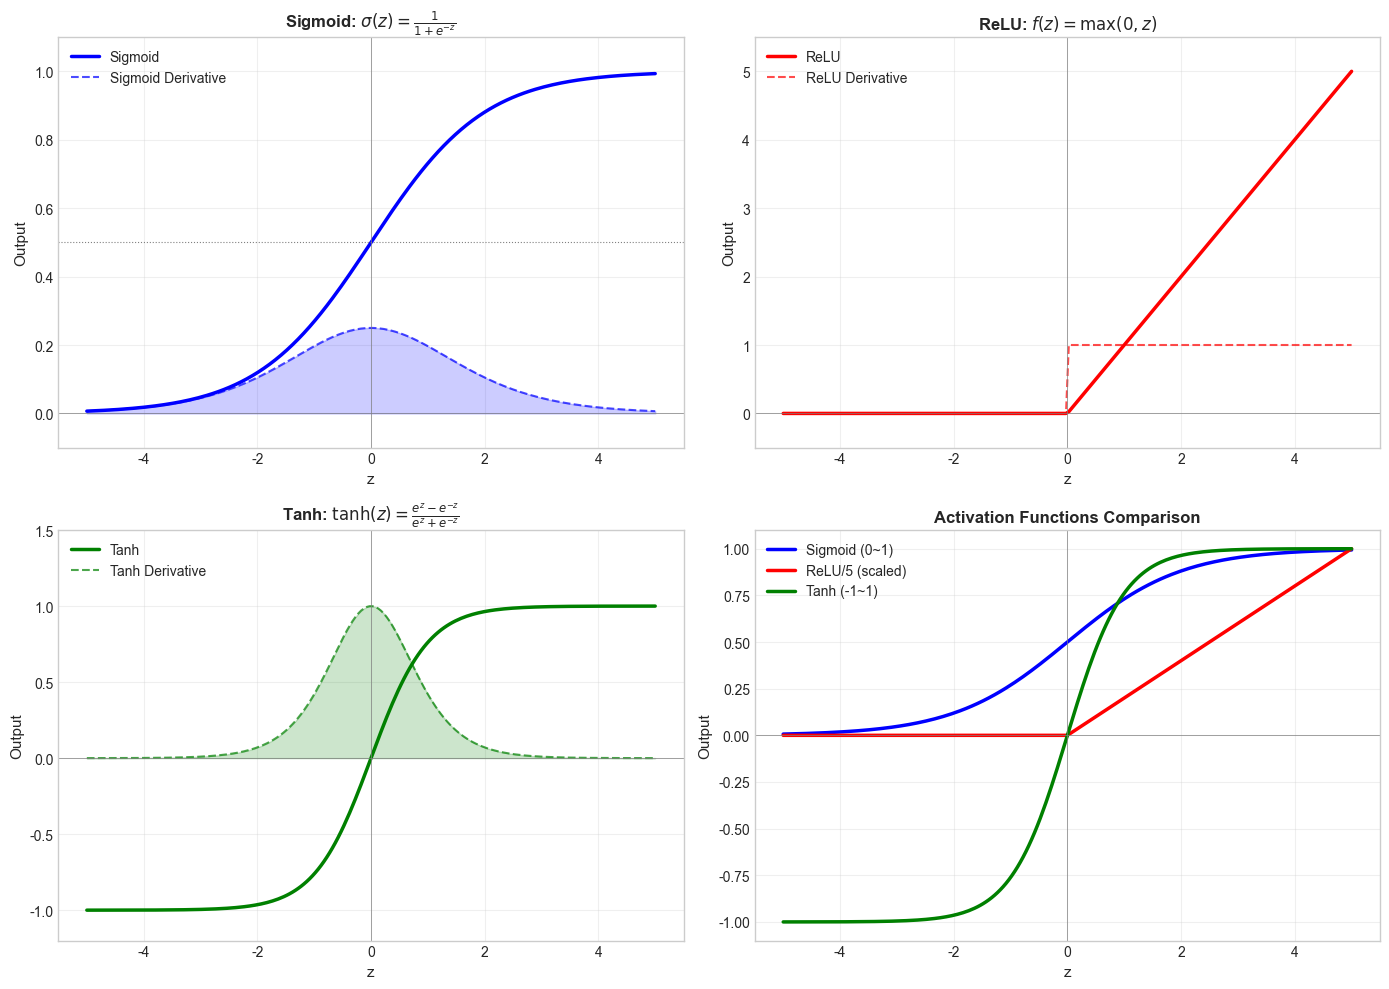

In [6]:
# 활성화 함수 시각화
z = np.linspace(-5, 5, 200)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Sigmoid
ax1 = axes[0, 0]
ax1.plot(z, sigmoid(z), 'b-', linewidth=2.5, label='Sigmoid')
ax1.plot(z, sigmoid_derivative(z), 'b--', linewidth=1.5, alpha=0.7, label='Sigmoid Derivative')
ax1.axhline(y=0.5, color='gray', linestyle=':', linewidth=0.8)
ax1.axhline(y=0, color='gray', linestyle='-', linewidth=0.5)
ax1.axvline(x=0, color='gray', linestyle='-', linewidth=0.5)
ax1.fill_between(z, 0, sigmoid_derivative(z), alpha=0.2, color='blue')
ax1.set_xlabel('z', fontsize=11)
ax1.set_ylabel('Output', fontsize=11)
ax1.set_title('Sigmoid: $\\sigma(z) = \\frac{1}{1+e^{-z}}$', fontweight='bold', fontsize=12)
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)
ax1.set_ylim(-0.1, 1.1)

# 2. ReLU
ax2 = axes[0, 1]
ax2.plot(z, relu(z), 'r-', linewidth=2.5, label='ReLU')
ax2.plot(z, relu_derivative(z), 'r--', linewidth=1.5, alpha=0.7, label='ReLU Derivative')
ax2.axhline(y=0, color='gray', linestyle='-', linewidth=0.5)
ax2.axvline(x=0, color='gray', linestyle='-', linewidth=0.5)
ax2.set_xlabel('z', fontsize=11)
ax2.set_ylabel('Output', fontsize=11)
ax2.set_title('ReLU: $f(z) = \\max(0, z)$', fontweight='bold', fontsize=12)
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)
ax2.set_ylim(-0.5, 5.5)

# 3. Tanh
ax3 = axes[1, 0]
ax3.plot(z, tanh_func(z), 'g-', linewidth=2.5, label='Tanh')
ax3.plot(z, tanh_derivative(z), 'g--', linewidth=1.5, alpha=0.7, label='Tanh Derivative')
ax3.axhline(y=0, color='gray', linestyle='-', linewidth=0.5)
ax3.axvline(x=0, color='gray', linestyle='-', linewidth=0.5)
ax3.fill_between(z, 0, tanh_derivative(z), alpha=0.2, color='green')
ax3.set_xlabel('z', fontsize=11)
ax3.set_ylabel('Output', fontsize=11)
ax3.set_title('Tanh: $\\tanh(z) = \\frac{e^z - e^{-z}}{e^z + e^{-z}}$', fontweight='bold', fontsize=12)
ax3.legend(loc='upper left')
ax3.grid(True, alpha=0.3)
ax3.set_ylim(-1.2, 1.5)

# 4. 모든 함수 비교
ax4 = axes[1, 1]
ax4.plot(z, sigmoid(z), 'b-', linewidth=2.5, label='Sigmoid (0~1)')
ax4.plot(z, relu(z)/5, 'r-', linewidth=2.5, label='ReLU/5 (scaled)')
ax4.plot(z, tanh_func(z), 'g-', linewidth=2.5, label='Tanh (-1~1)')
ax4.axhline(y=0, color='gray', linestyle='-', linewidth=0.5)
ax4.axvline(x=0, color='gray', linestyle='-', linewidth=0.5)
ax4.set_xlabel('z', fontsize=11)
ax4.set_ylabel('Output', fontsize=11)
ax4.set_title('Activation Functions Comparison', fontweight='bold', fontsize=12)
ax4.legend(loc='upper left')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('activation_functions.png', dpi=150, bbox_inches='tight')
plt.show()

## 2.3 활성화 함수 선택 가이드

| 활성화 함수 | 수식 | 출력 범위 | 주요 용도 | 장점 | 단점 |
|------------|------|----------|----------|------|------|
| **Sigmoid** | $\frac{1}{1+e^{-z}}$ | $(0, 1)$ | 이진 분류 출력층 | 확률 해석 가능 | 기울기 소실 |
| **ReLU** | $\max(0, z)$ | $[0, \infty)$ | 은닉층 표준 | 빠른 계산, 기울기 소실 완화 | Dying ReLU |
| **Tanh** | $\frac{e^z-e^{-z}}{e^z+e^{-z}}$ | $(-1, 1)$ | RNN, 0 중심 필요 시 | Zero-centered | 기울기 소실 |
| **Softmax** | $\frac{e^{z_i}}{\sum e^{z_j}}$ | $(0, 1)$, 합=1 | 다중 분류 출력층 | 확률 분포 출력 | 계산 비용 |

# 3. 신경망 구조와 순전파

## 3.1 다층 퍼셉트론(MLP) 구조

### 신경망의 층 구성

```
      입력층              은닉층 1            은닉층 2             출력층
    (Input Layer)      (Hidden Layer 1)   (Hidden Layer 2)    (Output Layer)
    
       [x1]                 [h1]               [h1']              [y1]
       [x2]   -----W1----> [h2]   -----W2---> [h2']  -----W3---> [y2]
       [x3]                 [h3]               [h3']              [y3]
       [x4]                 [h4]                                    
        +b1                  +b2                +b3
```

| 층 종류 | 역할 | 활성화 함수 |
|--------|------|------------|
| **입력층** | 특성 값을 받는 층, 뉴런 수 = 특성 수 | 없음 |
| **은닉층** | 입력과 출력 사이의 층, 패턴 학습 | ReLU (표준) |
| **출력층** | 최종 예측 출력 | Sigmoid/Softmax |

## 3.2 순전파 (Forward Propagation) 수학적 표현

### 2층 신경망의 순전파

입력: $\mathbf{x} \in \mathbb{R}^{n}$

**층 1 (은닉층):**
$$\mathbf{z}^{[1]} = \mathbf{W}^{[1]} \mathbf{x} + \mathbf{b}^{[1]}$$
$$\mathbf{a}^{[1]} = f^{[1]}(\mathbf{z}^{[1]}) \quad \text{(예: ReLU)}$$

**층 2 (출력층):**
$$\mathbf{z}^{[2]} = \mathbf{W}^{[2]} \mathbf{a}^{[1]} + \mathbf{b}^{[2]}$$
$$\mathbf{a}^{[2]} = f^{[2]}(\mathbf{z}^{[2]}) \quad \text{(예: Sigmoid)}$$

최종 출력: $\hat{\mathbf{y}} = \mathbf{a}^{[2]}$

### 행렬 표기법

배치(batch) 입력 $\mathbf{X} \in \mathbb{R}^{m \times n}$ (m개 샘플, n개 특성)에 대해:

$$\mathbf{Z}^{[1]} = \mathbf{X} \mathbf{W}^{[1]T} + \mathbf{b}^{[1]}$$
$$\mathbf{A}^{[1]} = f^{[1]}(\mathbf{Z}^{[1]})$$
$$\mathbf{Z}^{[2]} = \mathbf{A}^{[1]} \mathbf{W}^{[2]T} + \mathbf{b}^{[2]}$$
$$\hat{\mathbf{Y}} = f^{[2]}(\mathbf{Z}^{[2]})$$

```mermaid
flowchart LR
    subgraph Input["입력층"]
        X["X (m x n)"]
    end
    
    subgraph Hidden["은닉층 (ReLU)"]
        Z1["Z1 = X @ W1.T + b1"]
        A1["A1 = ReLU(Z1)"]
    end
    
    subgraph Output["출력층 (Sigmoid)"]
        Z2["Z2 = A1 @ W2.T + b2"]
        A2["Y_hat = Sigmoid(Z2)"]
    end
    
    X --> Z1
    Z1 --> A1
    A1 --> Z2
    Z2 --> A2
    A2 --> Pred["예측 결과"]
```

## 3.3 파라미터 수 계산

### 공식

층 $l$의 파라미터 수:
$$\text{파라미터 수} = (n^{[l-1]} \times n^{[l]}) + n^{[l]}$$

여기서:
- $n^{[l-1]}$: 이전 층의 뉴런 수
- $n^{[l]}$: 현재 층의 뉴런 수
- 첫째 항: 가중치 행렬 크기
- 둘째 항: 편향 벡터 크기

### 예시: 입력(64) -> 은닉(32) -> 출력(10)

| 층 | 가중치 크기 | 가중치 수 | 편향 수 | 총 파라미터 |
|---|------------|----------|--------|------------|
| 층 1 | (64, 32) | 2,048 | 32 | 2,080 |
| 층 2 | (32, 10) | 320 | 10 | 330 |
| **합계** | - | 2,368 | 42 | **2,410** |

In [7]:
def count_parameters(layer_sizes):
    """
    신경망의 총 파라미터 수를 계산
    
    Parameters:
    -----------
    layer_sizes : list, 각 층의 뉴런 수 [입력, 은닉1, 은닉2, ..., 출력]
    
    Returns:
    --------
    total_params : int, 총 파라미터 수
    """
    total_params = 0
    total_weights = 0
    total_biases = 0
    
    print("\n" + "=" * 60)
    print("신경망 파라미터 수 계산")
    print("=" * 60)
    print(f"\n네트워크 구조: {' -> '.join(map(str, layer_sizes))}")
    print("-" * 60)
    
    for i in range(len(layer_sizes) - 1):
        n_in = layer_sizes[i]
        n_out = layer_sizes[i + 1]
        weights = n_in * n_out
        biases = n_out
        layer_total = weights + biases
        
        total_weights += weights
        total_biases += biases
        total_params += layer_total
        
        print(f"층 {i+1} ({n_in} -> {n_out}):")
        print(f"  - 가중치 행렬: ({n_in} x {n_out}) = {weights:,}개")
        print(f"  - 편향 벡터:   ({n_out},) = {biases:,}개")
        print(f"  - 소계:        {layer_total:,}개")
    
    print("-" * 60)
    print(f"총 가중치: {total_weights:,}개")
    print(f"총 편향:   {total_biases:,}개")
    print(f"총 파라미터: {total_params:,}개")
    
    return total_params

# 예시 1: 간단한 네트워크
count_parameters([64, 32, 10])

# 예시 2: 더 깊은 네트워크
count_parameters([85, 64, 32, 16, 4])  # 유압 시스템 데이터용


신경망 파라미터 수 계산

네트워크 구조: 64 -> 32 -> 10
------------------------------------------------------------
층 1 (64 -> 32):
  - 가중치 행렬: (64 x 32) = 2,048개
  - 편향 벡터:   (32,) = 32개
  - 소계:        2,080개
층 2 (32 -> 10):
  - 가중치 행렬: (32 x 10) = 320개
  - 편향 벡터:   (10,) = 10개
  - 소계:        330개
------------------------------------------------------------
총 가중치: 2,368개
총 편향:   42개
총 파라미터: 2,410개

신경망 파라미터 수 계산

네트워크 구조: 85 -> 64 -> 32 -> 16 -> 4
------------------------------------------------------------
층 1 (85 -> 64):
  - 가중치 행렬: (85 x 64) = 5,440개
  - 편향 벡터:   (64,) = 64개
  - 소계:        5,504개
층 2 (64 -> 32):
  - 가중치 행렬: (64 x 32) = 2,048개
  - 편향 벡터:   (32,) = 32개
  - 소계:        2,080개
층 3 (32 -> 16):
  - 가중치 행렬: (32 x 16) = 512개
  - 편향 벡터:   (16,) = 16개
  - 소계:        528개
층 4 (16 -> 4):
  - 가중치 행렬: (16 x 4) = 64개
  - 편향 벡터:   (4,) = 4개
  - 소계:        68개
------------------------------------------------------------
총 가중치: 8,064개
총 편향:   116개
총 파라미터: 8,180개


8180

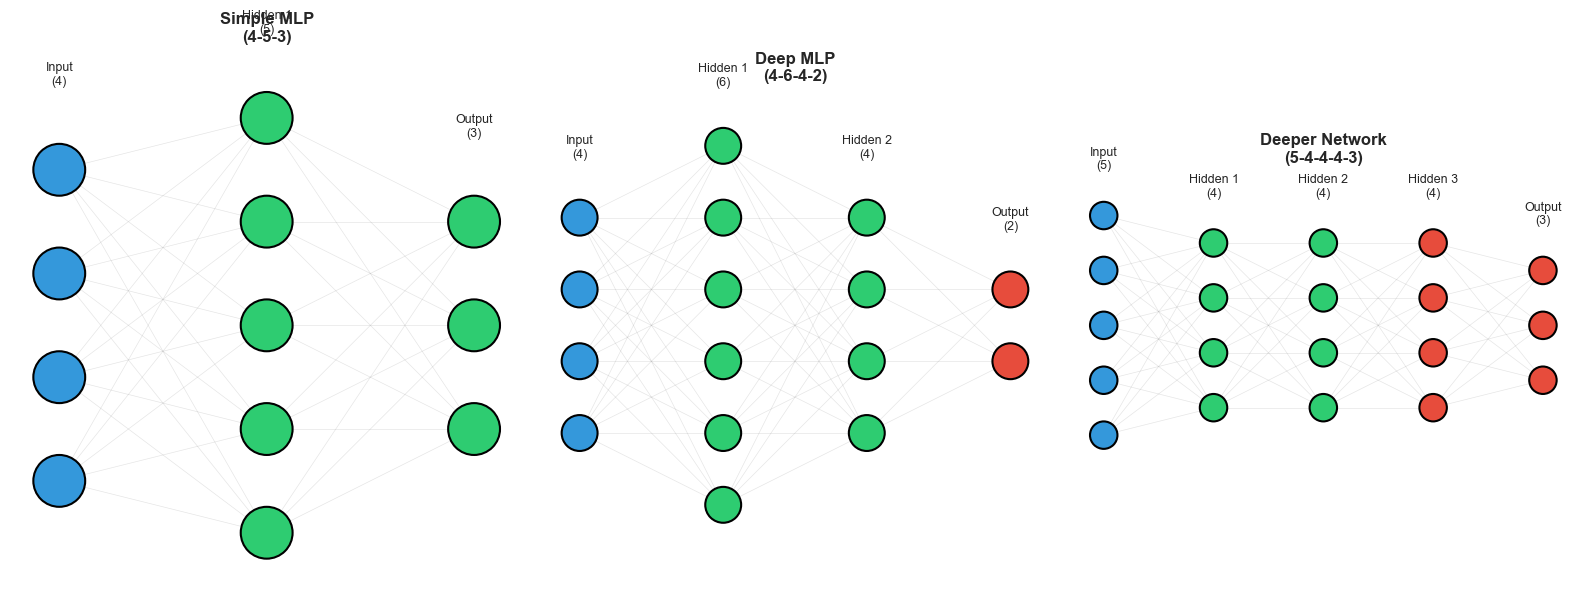

In [8]:
# 신경망 구조 시각화
def draw_neural_network(ax, layer_sizes, title):
    """
    신경망 구조를 시각화하는 함수
    """
    n_layers = len(layer_sizes)
    v_spacing = 1.0
    h_spacing = 2.0
    
    # 각 층의 노드 위치 계산
    layer_positions = []
    for i, size in enumerate(layer_sizes):
        x = i * h_spacing
        y_start = -(size - 1) * v_spacing / 2
        positions = [(x, y_start + j * v_spacing) for j in range(size)]
        layer_positions.append(positions)
    
    # 연결선 그리기
    for i in range(n_layers - 1):
        for pos1 in layer_positions[i]:
            for pos2 in layer_positions[i + 1]:
                ax.plot([pos1[0], pos2[0]], [pos1[1], pos2[1]],
                       'gray', alpha=0.2, linewidth=0.5, zorder=1)
    
    # 노드 그리기
    colors = ['#3498db', '#2ecc71', '#2ecc71', '#e74c3c']
    labels = ['Input', 'Hidden', 'Hidden', 'Output']
    
    for i, positions in enumerate(layer_positions):
        color = colors[min(i, len(colors)-1)]
        for j, pos in enumerate(positions):
            circle = plt.Circle(pos, 0.25, color=color, ec='black', 
                              linewidth=1.5, zorder=2)
            ax.add_patch(circle)
    
    # 층 레이블 추가
    for i, size in enumerate(layer_sizes):
        x = i * h_spacing
        y_top = (size - 1) * v_spacing / 2 + 0.8
        if i == 0:
            label = f'Input\n({size})'
        elif i == len(layer_sizes) - 1:
            label = f'Output\n({size})'
        else:
            label = f'Hidden {i}\n({size})'
        ax.text(x, y_top, label, ha='center', va='bottom', fontsize=9)
    
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(title, fontsize=12, fontweight='bold', pad=20)

# 다양한 네트워크 구조 시각화
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

draw_neural_network(axes[0], [4, 5, 3], 
                   'Simple MLP\n(4-5-3)')
draw_neural_network(axes[1], [4, 6, 4, 2], 
                   'Deep MLP\n(4-6-4-2)')
draw_neural_network(axes[2], [5, 4, 4, 4, 3], 
                   'Deeper Network\n(5-4-4-4-3)')

plt.tight_layout()
plt.savefig('neural_network_structures.png', dpi=150, bbox_inches='tight')
plt.show()

# 4: 역전파와 경사하강법

## 4.1 손실 함수 (Loss Function)

신경망의 성능을 측정하는 함수로, 예측값과 실제값의 차이를 정량화함.

### Mean Squared Error (MSE) - 회귀 문제

$$L_{MSE} = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2$$

**수치 계산 예시:**

실제값: $y = [3.0, 5.0, 7.0]$, 예측값: $\hat{y} = [2.5, 5.5, 6.5]$

$$L = \frac{1}{3}[(3.0-2.5)^2 + (5.0-5.5)^2 + (7.0-6.5)^2]$$
$$L = \frac{1}{3}[0.25 + 0.25 + 0.25] = \frac{0.75}{3} = 0.25$$

### Binary Cross-Entropy (BCE) - 이진 분류

$$L_{BCE} = -\frac{1}{n}\sum_{i=1}^{n}[y_i\log(\hat{y}_i) + (1-y_i)\log(1-\hat{y}_i)]$$

**수치 계산 예시:**

실제값: $y = 1$ (양성), 예측값: $\hat{y} = 0.9$
$$L = -[1 \times \log(0.9) + 0 \times \log(0.1)]$$
$$L = -\log(0.9) = -(-0.105) = 0.105$$

예측이 틀린 경우 ($\hat{y} = 0.1$):
$$L = -\log(0.1) = 2.303$$

예측이 정확할수록 손실이 작아짐.

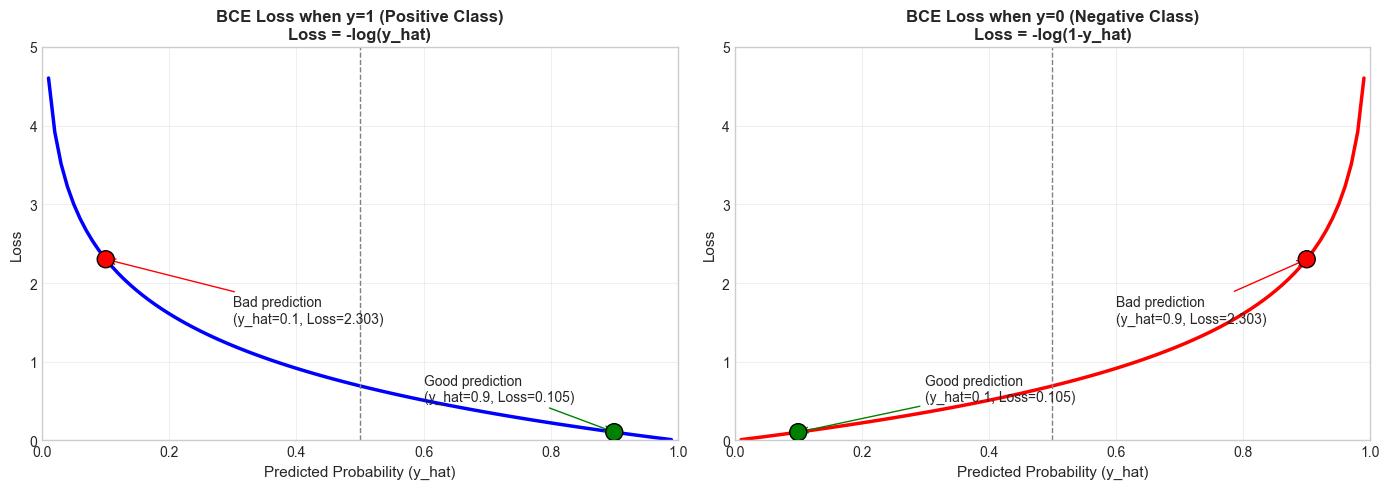

In [9]:
# 손실 함수 구현
def mse_loss(y_true, y_pred):
    """Mean Squared Error - 회귀 문제용"""
    return np.mean((y_true - y_pred) ** 2)

def binary_crossentropy(y_true, y_pred, epsilon=1e-8):
    """Binary Cross-Entropy - 이진 분류용"""
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)  # 수치 안정성
    return -np.mean(
        y_true * np.log(y_pred) + 
        (1 - y_true) * np.log(1 - y_pred)
    )

def categorical_crossentropy(y_true, y_pred, epsilon=1e-8):
    """Categorical Cross-Entropy - 다중 분류용"""
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
    return -np.mean(np.sum(y_true * np.log(y_pred), axis=1))

# Binary Cross-Entropy 시각화
y_pred_range = np.linspace(0.01, 0.99, 100)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 왼쪽: y=1일 때 손실
loss_y1 = -np.log(y_pred_range)
axes[0].plot(y_pred_range, loss_y1, 'b-', linewidth=2.5)
axes[0].axvline(x=0.5, color='gray', linestyle='--', linewidth=1)
axes[0].scatter([0.9, 0.1], [-np.log(0.9), -np.log(0.1)], 
               s=150, c=['green', 'red'], zorder=5, edgecolors='black')
axes[0].annotate('Good prediction\n(y_hat=0.9, Loss=0.105)', 
                xy=(0.9, -np.log(0.9)), xytext=(0.6, 0.5),
                arrowprops=dict(arrowstyle='->', color='green'),
                fontsize=10)
axes[0].annotate('Bad prediction\n(y_hat=0.1, Loss=2.303)', 
                xy=(0.1, -np.log(0.1)), xytext=(0.3, 1.5),
                arrowprops=dict(arrowstyle='->', color='red'),
                fontsize=10)
axes[0].set_xlabel('Predicted Probability (y_hat)', fontsize=11)
axes[0].set_ylabel('Loss', fontsize=11)
axes[0].set_title('BCE Loss when y=1 (Positive Class)\nLoss = -log(y_hat)', 
                 fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 5)

# 오른쪽: y=0일 때 손실
loss_y0 = -np.log(1 - y_pred_range)
axes[1].plot(y_pred_range, loss_y0, 'r-', linewidth=2.5)
axes[1].axvline(x=0.5, color='gray', linestyle='--', linewidth=1)
axes[1].scatter([0.1, 0.9], [-np.log(0.9), -np.log(0.1)], 
               s=150, c=['green', 'red'], zorder=5, edgecolors='black')
axes[1].annotate('Good prediction\n(y_hat=0.1, Loss=0.105)', 
                xy=(0.1, -np.log(0.9)), xytext=(0.3, 0.5),
                arrowprops=dict(arrowstyle='->', color='green'),
                fontsize=10)
axes[1].annotate('Bad prediction\n(y_hat=0.9, Loss=2.303)', 
                xy=(0.9, -np.log(0.1)), xytext=(0.6, 1.5),
                arrowprops=dict(arrowstyle='->', color='red'),
                fontsize=10)
axes[1].set_xlabel('Predicted Probability (y_hat)', fontsize=11)
axes[1].set_ylabel('Loss', fontsize=11)
axes[1].set_title('BCE Loss when y=0 (Negative Class)\nLoss = -log(1-y_hat)', 
                 fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 5)

plt.tight_layout()
plt.savefig('loss_function_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

## 4.2 역전파 (Backpropagation)

### 핵심 아이디어: 연쇄 법칙 (Chain Rule)

손실 함수 $L$을 가중치 $w$에 대해 미분하기 위해 **연쇄 법칙**을 사용함:

$$\frac{\partial L}{\partial w} = \frac{\partial L}{\partial a} \cdot \frac{\partial a}{\partial z} \cdot \frac{\partial z}{\partial w}$$

각 항의 의미:
- $\frac{\partial L}{\partial a}$: 출력에 대한 손실의 변화율 (손실 함수의 미분)
- $\frac{\partial a}{\partial z}$: 가중합에 대한 출력의 변화율 (활성화 함수의 미분)
- $\frac{\partial z}{\partial w}$: 가중치에 대한 가중합의 변화율 (입력값)

### 역전파 계산 예시 (단일 뉴런, Sigmoid + BCE)

**Forward Pass (순전파):**
- 입력: $x = 2$, 가중치: $w = 0.5$, 편향: $b = 0.1$
- 가중합: $z = wx + b = 0.5 \times 2 + 0.1 = 1.1$
- 출력: $a = \sigma(z) = \sigma(1.1) \approx 0.75$
- 실제값: $y = 1$
- 손실: $L = -\log(a) = -\log(0.75) \approx 0.288$

**Backward Pass (역전파):**

Sigmoid + BCE의 특별한 성질:
$$\frac{\partial L}{\partial z} = a - y$$

계산:
1. $\frac{\partial L}{\partial z} = a - y = 0.75 - 1 = -0.25$
2. $\frac{\partial L}{\partial w} = \frac{\partial L}{\partial z} \cdot x = -0.25 \times 2 = -0.5$
3. $\frac{\partial L}{\partial b} = \frac{\partial L}{\partial z} \cdot 1 = -0.25$

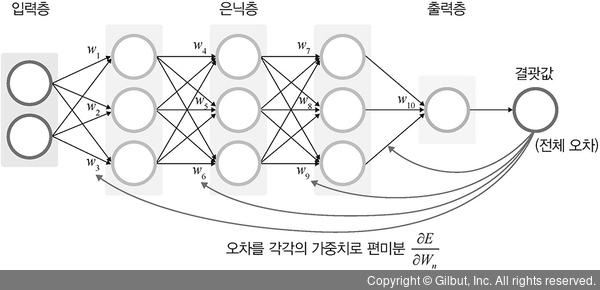

기울기가 음수이므로 가중치를 증가시켜야 손실이 감소함.

```mermaid
flowchart RL
    subgraph Forward["순전파 (Forward)"]
        direction LR
        X["x=2"] --> Z["z = wx + b = 1.1"]
        Z --> A["a = sigmoid(z) = 0.75"]
        A --> L["L = -log(a) = 0.288"]
    end
    
    subgraph Backward["역전파 (Backward)"]
        direction RL
        L2["dL/dz = a - y = -0.25"]
        L2 --> dW["dL/dw = dL/dz * x = -0.5"]
        L2 --> dB["dL/db = dL/dz = -0.25"]
    end
```

## 4.3 경사하강법 (Gradient Descent)

### 가중치 업데이트 공식

$$w_{new} = w_{old} - \eta \cdot \frac{\partial L}{\partial w}$$

여기서:
- $\eta$: 학습률 (learning rate)
- $\frac{\partial L}{\partial w}$: 손실 함수의 가중치에 대한 기울기

### 계산 예시

- 현재 가중치: $w = 0.5$
- 기울기: $\frac{\partial L}{\partial w} = -0.5$
- 학습률: $\eta = 0.1$

$$w_{new} = 0.5 - 0.1 \times (-0.5) = 0.5 + 0.05 = 0.55$$

기울기가 음수이므로 가중치가 증가함.

### 학습률의 중요성

| 학습률 | 특성 |
|--------|------|
| 너무 작음 | 수렴이 매우 느림, 지역 최솟값에 갇힐 수 있음 |
| 적절함 | 안정적이고 빠른 수렴 |
| 너무 큼 | 발산하거나 진동, 수렴하지 않음 |

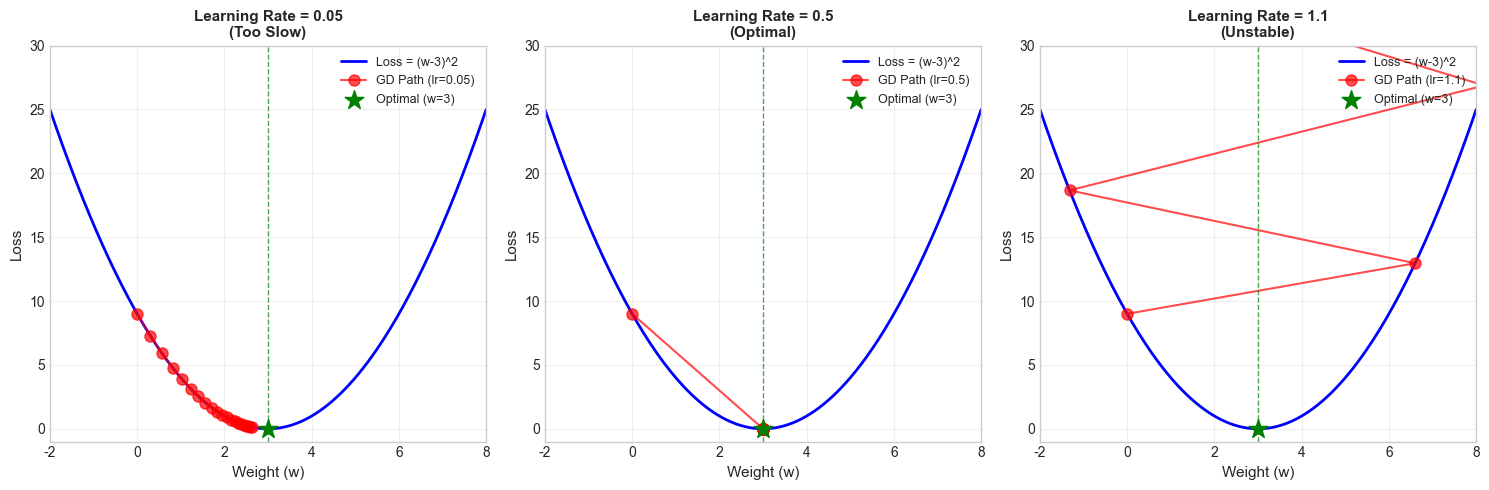


[학습률별 최종 가중치]
  lr=0.05: w_final = 2.6353, Loss = 0.1330
  lr=0.5: w_final = 3.0000, Loss = 0.0000
  lr=1.1: w_final = -112.0128, Loss = 13227.9441


In [10]:
# 학습률 효과 시각화
def simple_loss(w):
    """간단한 2차 손실 함수: L = (w - 3)^2"""
    return (w - 3) ** 2

def simple_gradient(w):
    """손실 함수의 기울기: dL/dw = 2(w - 3)"""
    return 2 * (w - 3)

def gradient_descent_path(start_w, lr, epochs):
    """경사하강법 경로 추적"""
    path = [start_w]
    w = start_w
    for _ in range(epochs):
        grad = simple_gradient(w)
        w = w - lr * grad
        path.append(w)
    return path

# 시각화
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
learning_rates = [0.05, 0.5, 1.1]
titles = ['Learning Rate = 0.05\n(Too Slow)', 
          'Learning Rate = 0.5\n(Optimal)', 
          'Learning Rate = 1.1\n(Unstable)']
w_range = np.linspace(-2, 8, 200)

for ax, lr, title in zip(axes, learning_rates, titles):
    # 손실 함수 곡선
    ax.plot(w_range, simple_loss(w_range), 'b-', linewidth=2, label='Loss = (w-3)^2')
    
    # 경사하강법 경로
    path = gradient_descent_path(0, lr, 20)
    path_losses = [simple_loss(w) for w in path]
    
    # 경로 시각화
    ax.plot(path, path_losses, 'ro-', markersize=8, linewidth=1.5, 
            alpha=0.7, label=f'GD Path (lr={lr})')
    
    # 최적점 표시
    ax.axvline(x=3, color='green', linestyle='--', linewidth=1, alpha=0.7)
    ax.scatter([3], [0], s=200, c='green', marker='*', zorder=5, label='Optimal (w=3)')
    
    ax.set_xlabel('Weight (w)', fontsize=11)
    ax.set_ylabel('Loss', fontsize=11)
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-2, 8)
    ax.set_ylim(-1, 30)

plt.tight_layout()
plt.savefig('learning_rate_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n[학습률별 최종 가중치]")
for lr in learning_rates:
    path = gradient_descent_path(0, lr, 20)
    print(f"  lr={lr}: w_final = {path[-1]:.4f}, Loss = {simple_loss(path[-1]):.4f}")

# 5 신경망 구현 및 실습

## 5.1 2층 신경망 클래스 구현

이제 지금까지 배운 내용을 바탕으로 완전한 2층 신경망을 구현함.

In [11]:
class SimpleNeuralNetwork:
    """
    2층 신경망 (입력 -> 은닉 -> 출력)
    
    구조:
    - 입력층: input_size개 뉴런
    - 은닉층: hidden_size개 뉴런, ReLU 활성화
    - 출력층: output_size개 뉴런, Sigmoid 활성화
    
    Parameters:
    -----------
    input_size : int, 입력 특성 수
    hidden_size : int, 은닉층 뉴런 수
    output_size : int, 출력층 뉴런 수
    learning_rate : float, 학습률
    """
    
    def __init__(self, input_size, hidden_size, output_size, learning_rate=0.01):
        self.lr = learning_rate
        
        # He 초기화 (ReLU용)
        self.W1 = np.random.randn(input_size, hidden_size) * np.sqrt(2.0 / input_size)
        self.b1 = np.zeros((1, hidden_size))
        
        # Xavier 초기화 (Sigmoid용)
        self.W2 = np.random.randn(hidden_size, output_size) * np.sqrt(1.0 / hidden_size)
        self.b2 = np.zeros((1, output_size))
        
        # 학습 기록
        self.loss_history = []
        self.accuracy_history = []
        
    def relu(self, z):
        """ReLU 활성화 함수"""
        return np.maximum(0, z)
    
    def relu_derivative(self, z):
        """ReLU 미분"""
        return (z > 0).astype(float)
    
    def sigmoid(self, z):
        """Sigmoid 활성화 함수"""
        return 1 / (1 + np.exp(-np.clip(z, -500, 500)))
    
    def forward(self, X):
        """
        순전파 (Forward Propagation)
        
        X -> Z1 -> A1 (ReLU) -> Z2 -> A2 (Sigmoid) -> Output
        """
        # 층 1: 입력 -> 은닉
        self.z1 = X @ self.W1 + self.b1
        self.a1 = self.relu(self.z1)
        
        # 층 2: 은닉 -> 출력
        self.z2 = self.a1 @ self.W2 + self.b2
        self.a2 = self.sigmoid(self.z2)
        
        return self.a2
    
    def compute_loss(self, y_true, y_pred):
        """
        Binary Cross-Entropy 손실 계산
        """
        epsilon = 1e-8
        y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
        loss = -np.mean(
            y_true * np.log(y_pred) + 
            (1 - y_true) * np.log(1 - y_pred)
        )
        return loss
    
    def backward(self, X, y_true):
        """
        역전파 (Backpropagation)
        
        연쇄 법칙을 사용하여 기울기 계산
        """
        m = X.shape[0]  # 샘플 수
        
        # 출력층 기울기
        # dL/dz2 = a2 - y (Sigmoid + BCE의 특별한 성질)
        dz2 = self.a2 - y_true
        dW2 = (self.a1.T @ dz2) / m
        db2 = np.mean(dz2, axis=0, keepdims=True)
        
        # 은닉층 기울기 (연쇄 법칙)
        da1 = dz2 @ self.W2.T
        dz1 = da1 * self.relu_derivative(self.z1)
        dW1 = (X.T @ dz1) / m
        db1 = np.mean(dz1, axis=0, keepdims=True)
        
        return dW1, db1, dW2, db2
    
    def update_parameters(self, dW1, db1, dW2, db2):
        """
        경사하강법으로 파라미터 업데이트
        """
        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1
        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2
    
    def train(self, X, y, epochs=1000, verbose=True, print_every=100):
        """
        신경망 학습
        """
        for epoch in range(epochs):
            # 1. 순전파
            y_pred = self.forward(X)
            
            # 2. 손실 계산
            loss = self.compute_loss(y, y_pred)
            self.loss_history.append(loss)
            
            # 3. 역전파
            dW1, db1, dW2, db2 = self.backward(X, y)
            
            # 4. 파라미터 업데이트
            self.update_parameters(dW1, db1, dW2, db2)
            
            # 5. 정확도 계산
            accuracy = self.evaluate(X, y)
            self.accuracy_history.append(accuracy)
            
            # 진행 상황 출력
            if verbose and (epoch + 1) % print_every == 0:
                print(f"  Epoch {epoch+1:5d}/{epochs}: "
                      f"Loss = {loss:.4f}, Accuracy = {accuracy:.2%}")
        
        return self.loss_history
    
    def predict(self, X, threshold=0.5):
        """
        예측 (이진 분류)
        """
        return (self.forward(X) >= threshold).astype(int)
    
    def evaluate(self, X, y):
        """
        정확도 평가
        """
        predictions = self.predict(X)
        return np.mean(predictions == y)
    
    def get_parameters(self):
        """
        현재 파라미터 반환
        """
        return {
            'W1': self.W1.copy(),
            'b1': self.b1.copy(),
            'W2': self.W2.copy(),
            'b2': self.b2.copy()
        }

print("SimpleNeuralNetwork 클래스 정의 완료")

SimpleNeuralNetwork 클래스 정의 완료


## 5.2 XOR 문제 학습

### XOR 문제란?

XOR(Exclusive OR)는 **선형 분리가 불가능**한 대표적인 문제임. 단층 퍼셉트론으로는 해결할 수 없으며, 다층 신경망의 필요성을 보여주는 역사적으로 중요한 문제임.

| $x_1$ | $x_2$ | XOR 출력 |
|-------|-------|----------|
| 0 | 0 | 0 |
| 0 | 1 | 1 |
| 1 | 0 | 1 |
| 1 | 1 | 0 |

In [22]:
# XOR 데이터 정의
X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_xor = np.array([[0], [1], [1], [0]])

print("=" * 60)
print("XOR 문제 학습")
print("=" * 60)
print("\n[XOR 진리표]")
print("┌─────┬─────┬───────┐")
print("│ x1  │ x2  │  XOR  │")
print("├─────┼─────┼───────┤")
for i in range(len(X_xor)):
    print(f"│  {X_xor[i,0]}  │  {X_xor[i,1]}  │   {y_xor[i,0]}   │")
print("└─────┴─────┴───────┘")

# 신경망 생성 및 학습
xor_nn = SimpleNeuralNetwork(
    input_size=2,
    hidden_size=1,  # 은닉층 뉴런 수
    output_size=1,
    learning_rate=1.0
)

print(f"\n[학습 진행]")
loss_history = xor_nn.train(X_xor, y_xor, epochs=1000, verbose=True, print_every=200)

XOR 문제 학습

[XOR 진리표]
┌─────┬─────┬───────┐
│ x1  │ x2  │  XOR  │
├─────┼─────┼───────┤
│  0  │  0  │   0   │
│  0  │  1  │   1   │
│  1  │  0  │   1   │
│  1  │  1  │   0   │
└─────┴─────┴───────┘

[학습 진행]
  Epoch   200/1000: Loss = 0.6931, Accuracy = 50.00%
  Epoch   400/1000: Loss = 0.6931, Accuracy = 50.00%
  Epoch   600/1000: Loss = 0.6931, Accuracy = 50.00%
  Epoch   800/1000: Loss = 0.6931, Accuracy = 50.00%
  Epoch  1000/1000: Loss = 0.6931, Accuracy = 50.00%


In [20]:
# XOR 학습 결과 확인
print("\n" + "=" * 60)
print("XOR 학습 결과")
print("=" * 60)

y_pred_prob = xor_nn.forward(X_xor)
y_pred = xor_nn.predict(X_xor)

print("\n[예측 결과]")
print("┌─────────────┬─────────────┬──────────┬──────────┐")
print("│   Input     │  Probability │ Predicted│  Actual  │")
print("├─────────────┼─────────────┼──────────┼──────────┤")
for i in range(len(X_xor)):
    correct = "" if y_pred[i,0] == y_xor[i,0] else "X"
    print(f"│ ({X_xor[i,0]}, {X_xor[i,1]})     │   {y_pred_prob[i,0]:.4f}    │    {y_pred[i,0]}     │    {y_xor[i,0]}     │ {correct}")
print("└─────────────┴─────────────┴──────────┴──────────┘")

accuracy = xor_nn.evaluate(X_xor, y_xor)
print(f"\n최종 정확도: {accuracy:.2%}")


XOR 학습 결과

[예측 결과]
┌─────────────┬─────────────┬──────────┬──────────┐
│   Input     │  Probability │ Predicted│  Actual  │
├─────────────┼─────────────┼──────────┼──────────┤
│ (0, 0)     │   0.6666    │    1     │    0     │ X
│ (0, 1)     │   0.6666    │    1     │    1     │ 
│ (1, 0)     │   0.6666    │    1     │    1     │ 
│ (1, 1)     │   0.0003    │    0     │    0     │ 
└─────────────┴─────────────┴──────────┴──────────┘

최종 정확도: 75.00%


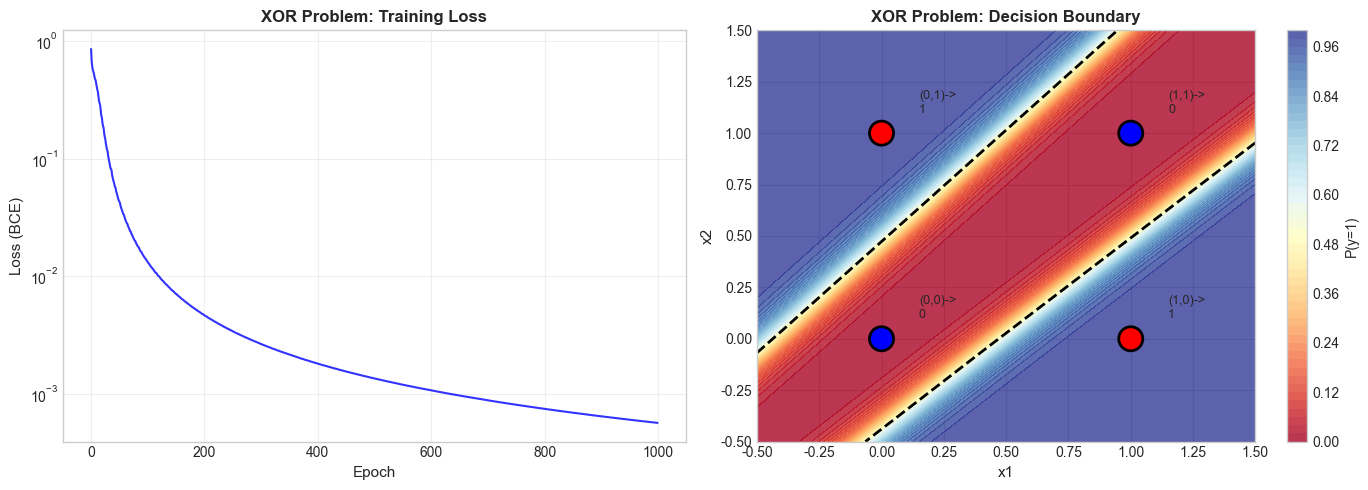


[해석]
- 신경망이 비선형 결정 경계를 학습하여 XOR 문제를 해결함
- 검은 점선: 결정 경계 (P=0.5)
- 단층 퍼셉트론으로는 불가능한 문제를 다층 신경망이 해결함


In [14]:
# XOR 학습 결과 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. 손실 곡선
ax1 = axes[0]
ax1.plot(xor_nn.loss_history, 'b-', linewidth=1.5, alpha=0.8)
ax1.set_xlabel('Epoch', fontsize=11)
ax1.set_ylabel('Loss (BCE)', fontsize=11)
ax1.set_title('XOR Problem: Training Loss', fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.set_yscale('log')

# 2. 결정 경계
ax2 = axes[1]
xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 200), np.linspace(-0.5, 1.5, 200))
grid_input = np.c_[xx.ravel(), yy.ravel()]
Z = xor_nn.forward(grid_input).reshape(xx.shape)

contour = ax2.contourf(xx, yy, Z, levels=50, cmap='RdYlBu', alpha=0.8)
plt.colorbar(contour, ax=ax2, label='P(y=1)')
ax2.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2, linestyles='--')

# 데이터 포인트 표시
colors = ['blue' if y == 0 else 'red' for y in y_xor.ravel()]
ax2.scatter(X_xor[:, 0], X_xor[:, 1], c=colors, s=300, 
           edgecolors='black', linewidths=2, zorder=5)

# 레이블 추가
for i, (x, y, label) in enumerate(zip(X_xor[:, 0], X_xor[:, 1], y_xor.ravel())):
    ax2.annotate(f'({int(x)},{int(y)})->\n{label}', 
                xy=(x, y), xytext=(x+0.15, y+0.1),
                fontsize=9, ha='left')

ax2.set_xlabel('x1', fontsize=11)
ax2.set_ylabel('x2', fontsize=11)
ax2.set_title('XOR Problem: Decision Boundary', fontweight='bold')
ax2.set_xlim(-0.5, 1.5)
ax2.set_ylim(-0.5, 1.5)

plt.tight_layout()
plt.savefig('xor_training_result.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n[해석]")
print("- 신경망이 비선형 결정 경계를 학습하여 XOR 문제를 해결함")
print("- 검은 점선: 결정 경계 (P=0.5)")
print("- 단층 퍼셉트론으로는 불가능한 문제를 다층 신경망이 해결함")

## 5.3 유압 시스템 데이터 로드 및 전처리

이제 실제 제조 데이터인 UCI Hydraulic System Condition Monitoring 데이터셋을 활용하여 신경망을 학습함.

In [23]:
# 데이터 로드
import urllib.request
import zipfile
import io
import ssl

ssl._create_default_https_context = ssl._create_unverified_context

print("=" * 70)
print("UCI Hydraulic System Condition Monitoring Dataset 로드")
print("=" * 70)

# 데이터셋 다운로드
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00447/data.zip"
print(f"\n데이터 소스: {url}")

response = urllib.request.urlopen(url)
print("데이터 다운로드 완료")

# 특징 추출
sensor_files = ['PS1.txt', 'PS2.txt', 'PS3.txt', 'PS4.txt', 'PS5.txt', 'PS6.txt',
                'TS1.txt', 'TS2.txt', 'TS3.txt', 'TS4.txt', 
                'VS1.txt', 'FS1.txt', 'FS2.txt', 'EPS1.txt', 
                'SE.txt', 'CE.txt', 'CP.txt']

features_list = []

with zipfile.ZipFile(io.BytesIO(response.read())) as z:
    print("\n[센서 데이터 로드 및 특징 추출]")
    
    for sensor_file in sensor_files:
        sensor_name = sensor_file.replace('.txt', '')
        with z.open(sensor_file) as f:
            data = pd.read_csv(f, delimiter='\t', header=None)
            
            # 각 샘플에 대해 통계적 특징 추출
            stats = pd.DataFrame({
                f'{sensor_name}_mean': data.mean(axis=1),
                f'{sensor_name}_std': data.std(axis=1),
                f'{sensor_name}_min': data.min(axis=1),
                f'{sensor_name}_max': data.max(axis=1),
                f'{sensor_name}_range': data.max(axis=1) - data.min(axis=1)
            })
            features_list.append(stats)
    
    # 레이블 로드
    with z.open('profile.txt') as f:
        labels = pd.read_csv(f, delimiter='\t', header=None)
        labels.columns = ['Cooler_condition', 'Valve_condition', 'Pump_leakage', 
                         'Accumulator_pressure', 'Stable_flag']

# 모든 특징 결합
X_hydraulic = pd.concat(features_list, axis=1)
print(f"\n특징 행렬 크기: {X_hydraulic.shape}")
print(f"샘플 수: {X_hydraulic.shape[0]}")
print(f"특징 수: {X_hydraulic.shape[1]}")

UCI Hydraulic System Condition Monitoring Dataset 로드

데이터 소스: https://archive.ics.uci.edu/ml/machine-learning-databases/00447/data.zip
데이터 다운로드 완료

[센서 데이터 로드 및 특징 추출]

특징 행렬 크기: (2205, 85)
샘플 수: 2205
특징 수: 85


In [24]:
# 이진 분류 문제로 변환: 밸브 상태가 정상(100)인지 아닌지
y_valve = (labels['Valve_condition'] == 100).astype(int).values.reshape(-1, 1)

print("\n[분류 레이블: 밸브 상태]")
print(f"  - Class 0 (비정상, <100): {np.sum(y_valve == 0)}개 ({np.mean(y_valve == 0)*100:.1f}%)")
print(f"  - Class 1 (정상, =100): {np.sum(y_valve == 1)}개 ({np.mean(y_valve == 1)*100:.1f}%)")

# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(
    X_hydraulic.values, y_valve, test_size=0.2, random_state=42, stratify=y_valve
)

print(f"\n[데이터 분할]")
print(f"  학습 데이터: {X_train.shape[0]}개")
print(f"  테스트 데이터: {X_test.shape[0]}개")

# 정규화 (StandardScaler)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\n[정규화 적용]")
print(f"  학습 데이터 평균: {X_train_scaled.mean():.6f}")
print(f"  학습 데이터 표준편차: {X_train_scaled.std():.6f}")


[분류 레이블: 밸브 상태]
  - Class 0 (비정상, <100): 1080개 (49.0%)
  - Class 1 (정상, =100): 1125개 (51.0%)

[데이터 분할]
  학습 데이터: 1764개
  테스트 데이터: 441개

[정규화 적용]
  학습 데이터 평균: -0.000000
  학습 데이터 표준편차: 0.982194


### 데이터 탐색적 분석

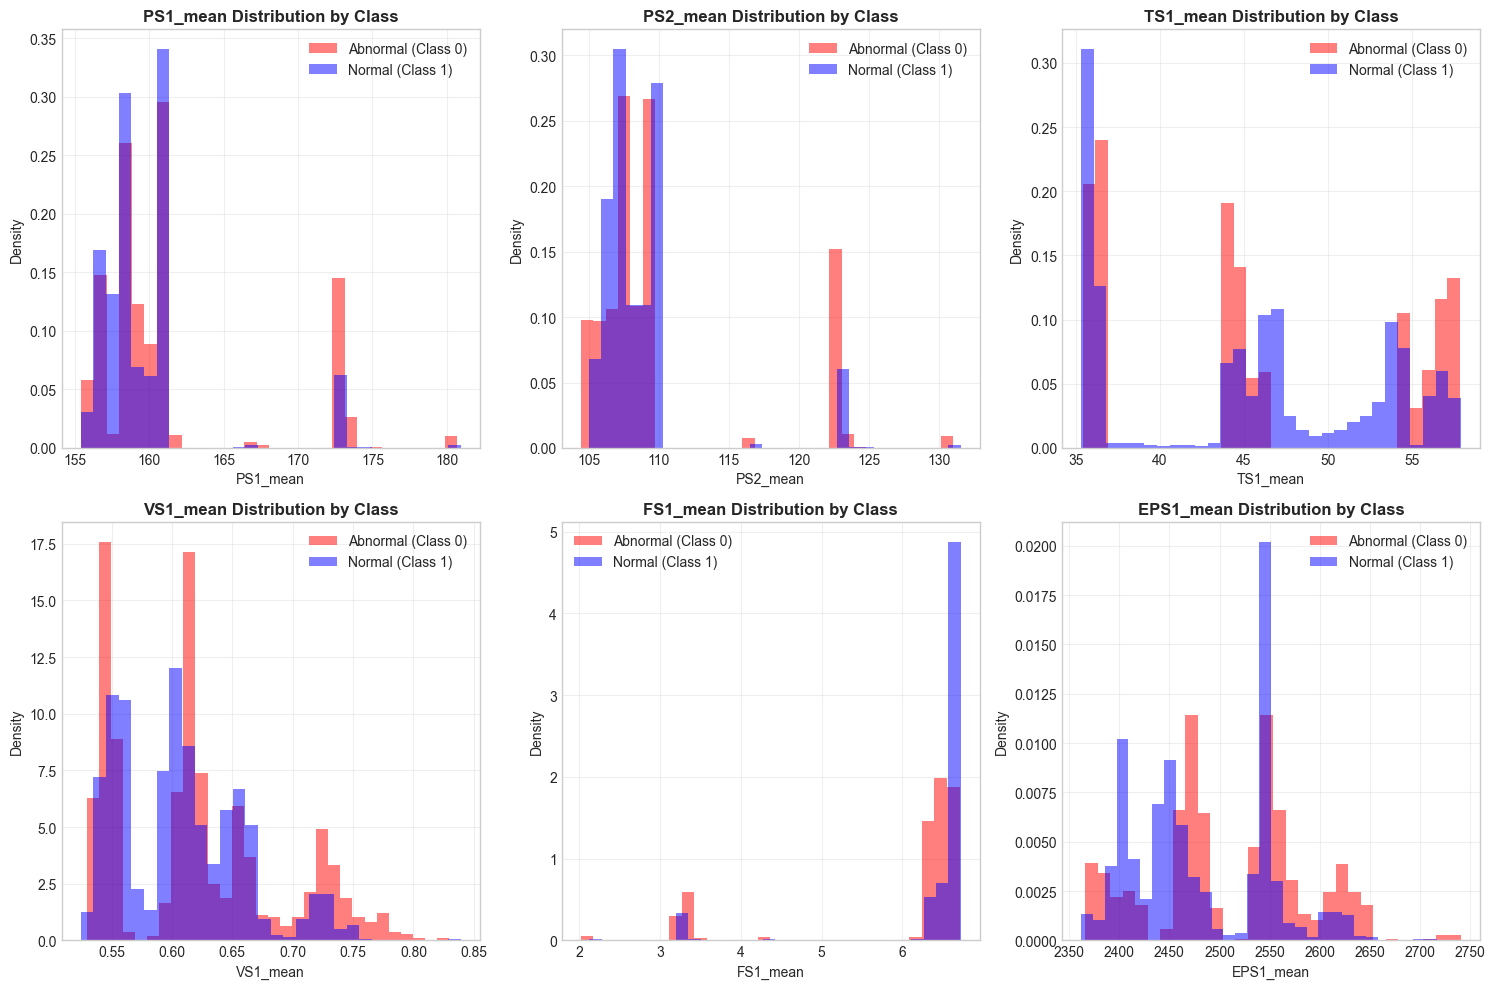


[해석]
- 정상(파란색)과 비정상(빨간색) 클래스 간 특징 분포 차이 확인
- 분포 차이가 큰 특징일수록 분류에 유용
- PS1_mean, PS2_mean 등 압력 센서 데이터가 클래스 구분에 중요할 것으로 예상


In [25]:
# 주요 특징의 분포 시각화
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 분석할 특징 선택
features_to_plot = ['PS1_mean', 'PS2_mean', 'TS1_mean', 'VS1_mean', 'FS1_mean', 'EPS1_mean']
feature_indices = [X_hydraulic.columns.get_loc(f) for f in features_to_plot]

for idx, (ax, feat_name, feat_idx) in enumerate(zip(axes.flat, features_to_plot, feature_indices)):
    # 클래스별 분포
    class_0 = X_hydraulic.iloc[y_valve.ravel() == 0, feat_idx]
    class_1 = X_hydraulic.iloc[y_valve.ravel() == 1, feat_idx]
    
    ax.hist(class_0, bins=30, alpha=0.5, label='Abnormal (Class 0)', color='red', density=True)
    ax.hist(class_1, bins=30, alpha=0.5, label='Normal (Class 1)', color='blue', density=True)
    
    ax.set_xlabel(feat_name, fontsize=10)
    ax.set_ylabel('Density', fontsize=10)
    ax.set_title(f'{feat_name} Distribution by Class', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('hydraulic_feature_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n[해석]")
print("- 정상(파란색)과 비정상(빨간색) 클래스 간 특징 분포 차이 확인")
print("- 분포 차이가 큰 특징일수록 분류에 유용")
print("- PS1_mean, PS2_mean 등 압력 센서 데이터가 클래스 구분에 중요할 것으로 예상")

## 5.4 유압 시스템 이진 분류 신경망 학습

In [28]:
# 신경망 생성 및 학습
print("=" * 70)
print("유압 시스템 밸브 상태 분류 신경망 학습")
print("=" * 70)

hydraulic_nn = SimpleNeuralNetwork(
    input_size=85,      # 특징 수
    hidden_size=32,     # 은닉층 뉴런 수
    output_size=1,      # 이진 분류
    learning_rate=0.1
)

print(f"\n[모델 구조]")
print(f"  입력층: 85개 뉴런")
print(f"  은닉층: 32개 뉴런 (ReLU)")
print(f"  출력층: 1개 뉴런 (Sigmoid)")
print(f"  학습률: 0.1")

# 파라미터 수 계산
total_params = (85 * 32 + 32) + (32 * 1 + 1)
print(f"  총 파라미터: {total_params:,}개")

print(f"\n[학습 진행]")
loss_history_hydraulic = hydraulic_nn.train(
    X_train_scaled, y_train, 
    epochs=1000, 
    verbose=True, 
    print_every=100
)

유압 시스템 밸브 상태 분류 신경망 학습

[모델 구조]
  입력층: 85개 뉴런
  은닉층: 32개 뉴런 (ReLU)
  출력층: 1개 뉴런 (Sigmoid)
  학습률: 0.1
  총 파라미터: 2,785개

[학습 진행]
  Epoch   100/1000: Loss = 0.5294, Accuracy = 73.30%
  Epoch   200/1000: Loss = 0.4556, Accuracy = 78.63%
  Epoch   300/1000: Loss = 0.3980, Accuracy = 81.97%
  Epoch   400/1000: Loss = 0.3479, Accuracy = 85.15%
  Epoch   500/1000: Loss = 0.3004, Accuracy = 88.44%
  Epoch   600/1000: Loss = 0.3107, Accuracy = 87.13%
  Epoch   700/1000: Loss = 0.2812, Accuracy = 88.83%
  Epoch   800/1000: Loss = 0.2557, Accuracy = 90.14%
  Epoch   900/1000: Loss = 0.2279, Accuracy = 91.78%
  Epoch  1000/1000: Loss = 0.2164, Accuracy = 91.89%


In [29]:
# 모델 평가
print("\n" + "=" * 70)
print("모델 평가 결과")
print("=" * 70)

# 학습 데이터 성능
train_accuracy = hydraulic_nn.evaluate(X_train_scaled, y_train)
print(f"\n학습 데이터 정확도: {train_accuracy:.2%}")

# 테스트 데이터 성능
test_accuracy = hydraulic_nn.evaluate(X_test_scaled, y_test)
print(f"테스트 데이터 정확도: {test_accuracy:.2%}")

# 혼동 행렬
y_pred_test = hydraulic_nn.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred_test)

print(f"\n[혼동 행렬]")
print(f"                 예측")
print(f"              비정상  정상")
print(f"실제 비정상     {cm[0,0]:4d}   {cm[0,1]:4d}")
print(f"     정상       {cm[1,0]:4d}   {cm[1,1]:4d}")

# 분류 리포트
print(f"\n[분류 리포트]")
print(classification_report(y_test, y_pred_test, target_names=['비정상', '정상']))


모델 평가 결과

학습 데이터 정확도: 91.89%
테스트 데이터 정확도: 90.25%

[혼동 행렬]
                 예측
              비정상  정상
실제 비정상      196     20
     정상         23    202

[분류 리포트]
              precision    recall  f1-score   support

         비정상       0.89      0.91      0.90       216
          정상       0.91      0.90      0.90       225

    accuracy                           0.90       441
   macro avg       0.90      0.90      0.90       441
weighted avg       0.90      0.90      0.90       441



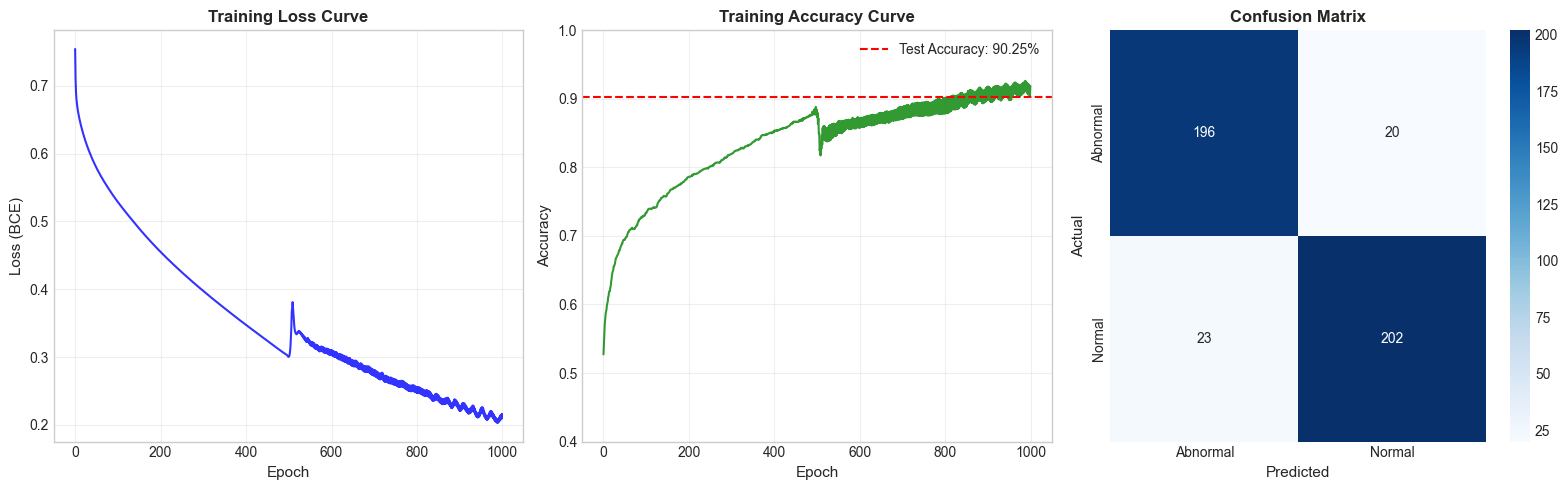

In [30]:
# 학습 결과 시각화
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. 손실 곡선
ax1 = axes[0]
ax1.plot(hydraulic_nn.loss_history, 'b-', linewidth=1.5, alpha=0.8)
ax1.set_xlabel('Epoch', fontsize=11)
ax1.set_ylabel('Loss (BCE)', fontsize=11)
ax1.set_title('Training Loss Curve', fontweight='bold')
ax1.grid(True, alpha=0.3)

# 2. 정확도 곡선
ax2 = axes[1]
ax2.plot(hydraulic_nn.accuracy_history, 'g-', linewidth=1.5, alpha=0.8)
ax2.axhline(y=test_accuracy, color='r', linestyle='--', label=f'Test Accuracy: {test_accuracy:.2%}')
ax2.set_xlabel('Epoch', fontsize=11)
ax2.set_ylabel('Accuracy', fontsize=11)
ax2.set_title('Training Accuracy Curve', fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0.4, 1.0)

# 3. 혼동 행렬 히트맵
ax3 = axes[2]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax3,
           xticklabels=['Abnormal', 'Normal'],
           yticklabels=['Abnormal', 'Normal'])
ax3.set_xlabel('Predicted', fontsize=11)
ax3.set_ylabel('Actual', fontsize=11)
ax3.set_title('Confusion Matrix', fontweight='bold')

plt.tight_layout()
plt.savefig('hydraulic_training_results.png', dpi=150, bbox_inches='tight')
plt.show()

## 5.6 학습률 비교 실험

In [31]:
# 다양한 학습률 실험
print("=" * 70)
print("학습률 비교 실험")
print("=" * 70)

learning_rates = [0.001, 0.01, 0.1, 0.5]
experiments = {}

for lr in learning_rates:
    np.random.seed(42)
    nn_exp = SimpleNeuralNetwork(
        input_size=85,
        hidden_size=32,
        output_size=1,
        learning_rate=lr
    )
    
    loss_hist = nn_exp.train(
        X_train_scaled, y_train,
        epochs=300,
        verbose=False
    )
    
    test_acc = nn_exp.evaluate(X_test_scaled, y_test)
    experiments[lr] = {
        'loss_history': loss_hist,
        'test_accuracy': test_acc,
        'final_loss': loss_hist[-1]
    }
    
    print(f"  lr={lr}: Final Loss={loss_hist[-1]:.4f}, Test Acc={test_acc:.2%}")

학습률 비교 실험
  lr=0.001: Final Loss=0.6918, Test Acc=52.15%
  lr=0.01: Final Loss=0.6039, Test Acc=70.29%
  lr=0.1: Final Loss=0.3657, Test Acc=84.58%
  lr=0.5: Final Loss=0.2889, Test Acc=87.76%


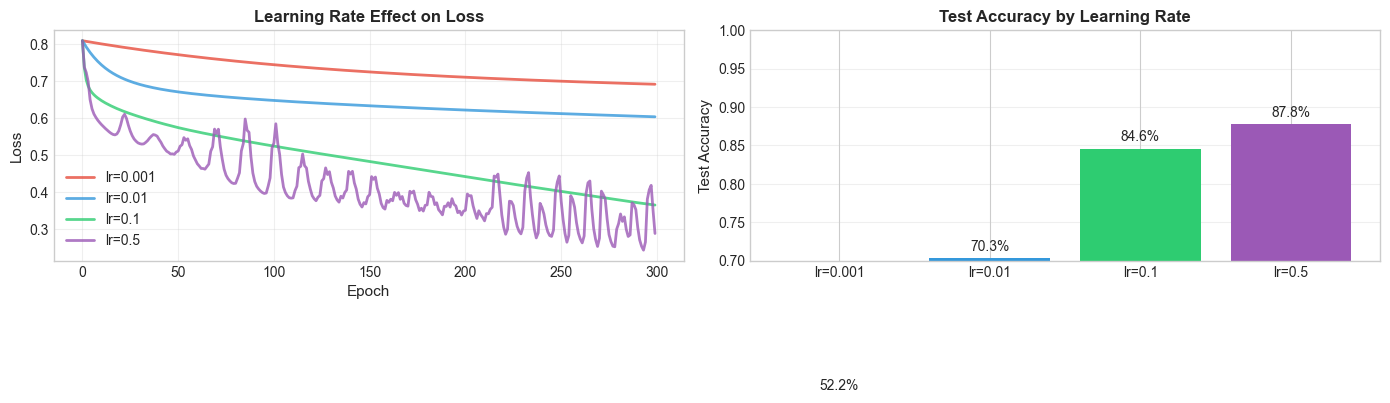


[학습률 선택 가이드]
  - 너무 작은 학습률(0.001): 수렴이 느리고 성능 향상 제한적
  - 적절한 학습률(0.01~0.1): 안정적이고 빠른 수렴
  - 너무 큰 학습률(0.5+): 초기에 빠르지만 불안정할 수 있음


In [32]:
# 학습률 비교 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6']

# 손실 곡선
ax1 = axes[0]
for (lr, exp_data), color in zip(experiments.items(), colors):
    ax1.plot(exp_data['loss_history'], linewidth=2, label=f'lr={lr}', color=color, alpha=0.8)
ax1.set_xlabel('Epoch', fontsize=11)
ax1.set_ylabel('Loss', fontsize=11)
ax1.set_title('Learning Rate Effect on Loss', fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 테스트 정확도 비교
ax2 = axes[1]
lrs = list(experiments.keys())
accs = [experiments[lr]['test_accuracy'] for lr in lrs]
bars = ax2.bar(range(len(lrs)), accs, color=colors)
ax2.set_xticks(range(len(lrs)))
ax2.set_xticklabels([f'lr={lr}' for lr in lrs])
ax2.set_ylabel('Test Accuracy', fontsize=11)
ax2.set_title('Test Accuracy by Learning Rate', fontweight='bold')
ax2.set_ylim(0.7, 1.0)
ax2.grid(True, alpha=0.3, axis='y')

# 정확도 레이블 추가
for bar, acc in zip(bars, accs):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{acc:.1%}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('learning_rate_experiment.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n[학습률 선택 가이드]")
print("  - 너무 작은 학습률(0.001): 수렴이 느리고 성능 향상 제한적")
print("  - 적절한 학습률(0.01~0.1): 안정적이고 빠른 수렴")
print("  - 너무 큰 학습률(0.5+): 초기에 빠르지만 불안정할 수 있음")

# 차시 요약

## 핵심 개념 정리

### 1. 인공 뉴런의 수학적 모델

$$a = f\left(\sum_{i=1}^{n} w_i x_i + b\right) = f(z)$$

| 요소 | 역할 |
|------|------|
| 가중치 ($w$) | 입력의 중요도, 학습 대상 |
| 편향 ($b$) | 결정 경계 조정, 학습 대상 |
| 활성화 함수 ($f$) | 비선형성 부여 |

### 2. 주요 활성화 함수

| 함수 | 수식 | 용도 |
|------|------|------|
| Sigmoid | $\sigma(z) = \frac{1}{1+e^{-z}}$ | 이진 분류 출력층 |
| ReLU | $f(z) = \max(0, z)$ | 은닉층 표준 |
| Softmax | $\frac{e^{z_i}}{\sum e^{z_j}}$ | 다중 분류 출력층 |

### 3. 역전파와 경사하강법

**연쇄 법칙:**
$$\frac{\partial L}{\partial w} = \frac{\partial L}{\partial a} \cdot \frac{\partial a}{\partial z} \cdot \frac{\partial z}{\partial w}$$

**가중치 업데이트:**
$$w_{new} = w_{old} - \eta \cdot \frac{\partial L}{\partial w}$$

### 4. 학습 권장 사항

| 항목 | 권장 |
|------|------|
| 데이터 전처리 | StandardScaler 적용 필수 |
| 학습률 | 0.01 ~ 0.1 범위에서 시작 |
| 가중치 초기화 | He (ReLU), Xavier (Sigmoid) |